## Project Exercise Week of March 17

Goal today: DiD example with census data

In [1]:
library(tidyverse)
library(haven)
library(stargazer)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 




In [2]:
df <- read_dta("cen_ind_2021_pumf_v2.dta") %>% 
    filter((agegrp >= 16 & agegrp < 88) & 
          !ageimm %in% c(88, 99) &
          !lfact %in% c(88, 99))

In [3]:
df$agegrp <- as_factor(df$agegrp)  # This retains Stata labels as factor levels

In [4]:
df <- df %>% 
    mutate(retired = ifelse(lfact >=1 & lfact <= 10, 0, 1),
          eligible = factor(ifelse(ageimm < 13, 1, 0)))

Comparison group:
Immigrants arriving before and after 60 years old
Retirement Status Post 65 v.s. pre 65

Parallel Trend Assumption: common trend in retirement for the two groups of people. The OAS eligible group (early mover) would have shared the same trend in retirment as the inelibigle group had there been no OAS program.

Is this reasonable? 
- moving early v.s. moving late
    - reason for immigration
    - difficulty to find a job, types of jobs.

### Summary Statistics: Retire by age group and immigration status

`summarise()` has grouped output by 'eligible'. You can override using the
`.groups` argument.


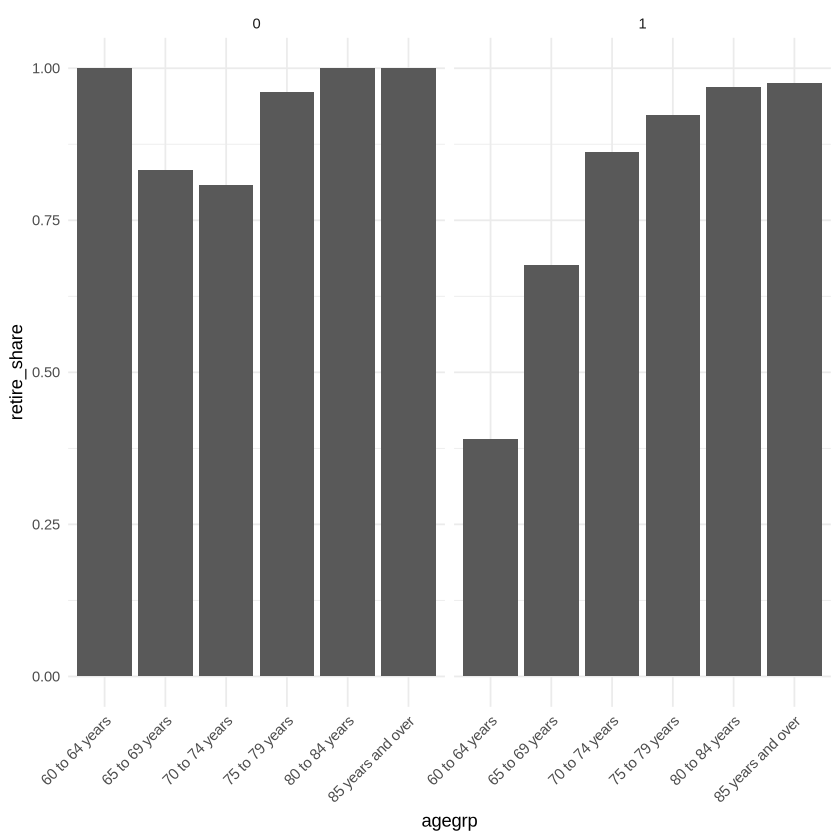

In [5]:
df %>% 
    group_by(eligible, agegrp) %>% 
    summarise(retire_share = mean(retired)) %>%
    ggplot(aes(x = agegrp, y = retire_share)) +
    facet_wrap(~eligible) +
    geom_col(position="dodge") +
    theme_minimal()+ #aesthetic
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) #aesthetic


In [15]:
reg1 = lm(data=df, retired ~ eligible)
reg2 = lm(data=df, retired ~ eligible + agegrp)
reg3 = lm(data=df, retired ~ eligible * agegrp)
stargazer(reg1, reg2, reg3, type = "text")


                                                              Dependent variable:                            
                                  ---------------------------------------------------------------------------
                                                                    retired                                  
                                            (1)                      (2)                       (3)           
-------------------------------------------------------------------------------------------------------------
eligible1                                -0.207***                 -0.063*                  -0.610***        
                                          (0.040)                  (0.036)                   (0.172)         
                                                                                                             
agegrp65 to 69 years                                               0.287***                  -0.167          
         